In [59]:
import pandas as pd
strongs_df = pd.read_csv("greek-lxx-ot-blb.csv", dtype={'strong_num': str})
enhancd_df = pd.read_csv("20260311_152938_biblehub_LXX_EXT_el_en_direct.csv")

In [ ]:
strongs_df.head()

In [ ]:
enhancd_df.head()

In [ ]:
strongs_df.query(
    "book == 'hosea' and chapter == 3"
)[:10]

In [60]:
def prepare_grouped(strongs_df, enhancd_df):
    strongs_g = strongs_df.groupby(["book", "chapter", "verse"])
    enc_g = enhancd_df.groupby(["book", "chapter", "verse"])
    return strongs_g, enc_g
strongs_g, enc_g = prepare_grouped(strongs_df, enhancd_df)    

In [61]:
map_blb_to_aposto = {
("1_kings", 22, 50): ("1_kings", 22, 49),
("1_kings", 22, 51): ("1_kings", 22, 50),
("1_kings", 22, 52): ("1_kings", 22, 51),
("1_kings", 22, 53): ("1_kings", 22, 52),
('proverbs', 16, 2): None,
('proverbs', 16, 4): None,
('proverbs', 16, 7): None,
('proverbs', 16, 8): None,
('proverbs', 24, 8): None
}
keyss = sorted(strongs_g.groups.keys())
for i, key in enumerate(keyss):
    b, chapter, verse = key
    if key not in enc_g.groups and key not in map_blb_to_aposto:
        print(f"⚠️ {key} not in Enhanced numbers gk!")

In [ ]:
for i, key in enumerate(keyss):
    b, chapter, verse = key
    strongs_verse = strongs_g.get_group(key)
    enckey = map_blb_to_aposto.get(key, key)
    if enckey is None:
        continue
    enc_verse = enc_g.get_group(enckey)
    print(strongs_verse)
    print("~"*50)
    print(enc_verse)
    if(len(strongs_verse) != len(enc_verse)):
        strong_sorted = strongs_verse.sort_values("word")
        #strong_data_list = strong_sorted.to_dict("records")
        #print (strong_data_list)
        #return
        strong_text = " ".join(
            strong_sorted["form"].astype(str)
        )
        enc_sorted = enc_verse.sort_values("word_idx")
        #enc_data_list = enc_sorted.to_dict("records")
        #print (strong_data_list)
        #return
        enc_text = " ".join(
            enc_sorted["form"].astype(str)
        )
        print(enc_text)
        print(strong_text)
        break
    #if key not in enc_g.groups and key not in map_blb_to_aposto:
    #    print(f"⚠️ {key} not in Enhanced numbers gk!")

In [ ]:
for i in range(50, 54):
    print(f'("1_kings", 22, {str(i)}): ("1_kings", 22, {str(i-1)}),')

In [62]:
# 1. Atrodam vārdus bez Strong numuriem
voids_df = strongs_df[
    (strongs_df["strong_num"].isna()) | 
    (strongs_df["strong_num"] == 0) | 
    (strongs_df["strong_num"] == "")
].copy()



In [63]:
voids_df.head()

,verse,word,form,strong_num,strong_en_title,book,chapter
16,2,6,ἀκατασκεύαστος,NaN,Adj-NSM,genesis,1
47,4,9,διεχώρισεν,NaN,V-AAI-3S,genesis,1
91,6,12,διαχωρίζον,NaN,V-PAP-NSN,genesis,1
107,7,7,διεχώρισεν,NaN,V-AAI-3S,genesis,1
195,10,9,συστήματα,NaN,N-APN,genesis,1


In [ ]:
enc_g.get_group(("genesis", 1, 2))[:6]

In [ ]:
for i, key in enumerate(keyss):
    b, chapter, verse = key
    strongs_verse = strongs_g.get_group(key)
    if len(strongs_verse) < 1:
        print(key)

In [ ]:
strongs_g.get_group(("1_kings", 22, 49)).head()

In [ ]:
ot_only=True
bkslist = ["genesis", "exodus", "leviticus", "numbers", "deuteronomy", "joshua", "judges", "ruth", "1_samuel", "2_samuel", "1_kings", "2_kings", "1_chronicles", "2_chronicles", "ezra", "nehemiah", "esther", "job", "psalms", "proverbs", "ecclesiastes", "songs", "isaiah", "jeremiah", "lamentations", "ezekiel", "daniel", "hosea", "joel", "amos", "obadiah", "jonah", "micah", "nahum", "habakkuk", "zephaniah", "haggai", "zechariah", "malachi", "matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]
chps= [int(i) for i in "50 40 27 36 34 24 21 4 31 24 22 25 29 36 10 13 10 42 150 31 12 8 66 52 5 48 12 14 3 9 1 4 7 3 3 3 2 14 4 28 16 24 21 28 16 16 13 6 6 4 4 5 3 6 4 3 1 13 5 5 3 5 1 1 1 22".split(" ")]
idxl = {}
names = {}
revnames = {}
nt_stubchapters = ["matthew", "mark", "luke", "john", "acts", "romans", "1_corinthians", "2_corinthians", "galatians", "ephesians", "philippians", "colossians", "1_thessalonians", "2_thessalonians", "1_timothy", "2_timothy", "titus", "philemon", "hebrews", "james", "1_peter", "2_peter", "1_john", "2_john", "3_john", "jude", "revelation"]
for i in range (len(bkslist)):
    if (bkslist[i] not in nt_stubchapters if ot_only else True):
        names[bkslist[i]] = chps[i]

In [ ]:
for b, chmax in names.items():
    for ch in range(1, chmax+1):
        if (b, ch):
            ...
    #VEEEEEEEEEEEERSES

In [64]:
import unicodedata

def strip_accents(s):
    if not isinstance(s, str): return ""
    return ''.join(c for c in unicodedata.normalize('NFD', s)
                  if unicodedata.category(c) != 'Mn').lower()


def find_extended_match(row, ext_group):
    source_word = strip_accents(row['form'])
    if not source_word: return None
    
    best_match = None
    
    for _, ext_row in ext_group.iterrows():
        target_word = strip_accents(ext_row['form'])
        
        # 1. Pārbaudām tiešu sakritību vai "4 no 5" burtu loģiku
        # (Vienkāršots: ja vārds ir garš, meklējam apakšstringu vai augstu sakritību)
        if source_word == target_word or (len(source_word) >= 4 and source_word[:4] in target_word) \
        or (len(source_word) >= 4 and source_word[-4] in target_word):
            
            s_num = str(ext_row['strong_num'])
            
            # 2. prioritāte: ne-integeri (piem. G1234.5 vai "3588a")
            # Tie parasti ir tieši tie, kas pievienoti LXX specifikai
            #is_extended_num = any(c in s_num for c in ".-abcdefghijklmnopqrstuvwxyz")
            if "." in s_num:
                return s_num # Uzreiz ņemam šo, jo tas ir specifisks LXX
            
            best_match = s_num
            
    return best_match

In [65]:
results = []

for idx, row in voids_df.iterrows():
    key = (row['book'], row['chapter'], row['verse'])
    
    # Izmantojam tavu remapperi, ja nepieciešams
    lookup_key = map_blb_to_aposto.get(key, key)
    if lookup_key is None:
        continue
    
    ext_group = enc_g.get_group(lookup_key)
    new_num = find_extended_match(row, ext_group)
    
    if new_num:
        strongs_df.at[idx, 'strong_num'] = new_num
        strongs_df.at[idx, 'is_patched'] = True # Atzīme analīzei

print(f"Aizpildīti {strongs_df['is_patched'].sum()} trūkstošie numuri.")

Aizpildīti 30062 trūkstošie numuri.


In [69]:
len(voids_df)

30332

In [70]:
voids_df = strongs_df[
    (strongs_df["strong_num"].isna()) | 
    (strongs_df["strong_num"] == 0) | 
    (strongs_df["strong_num"] == "")
].copy()


In [71]:
len(voids_df)

270

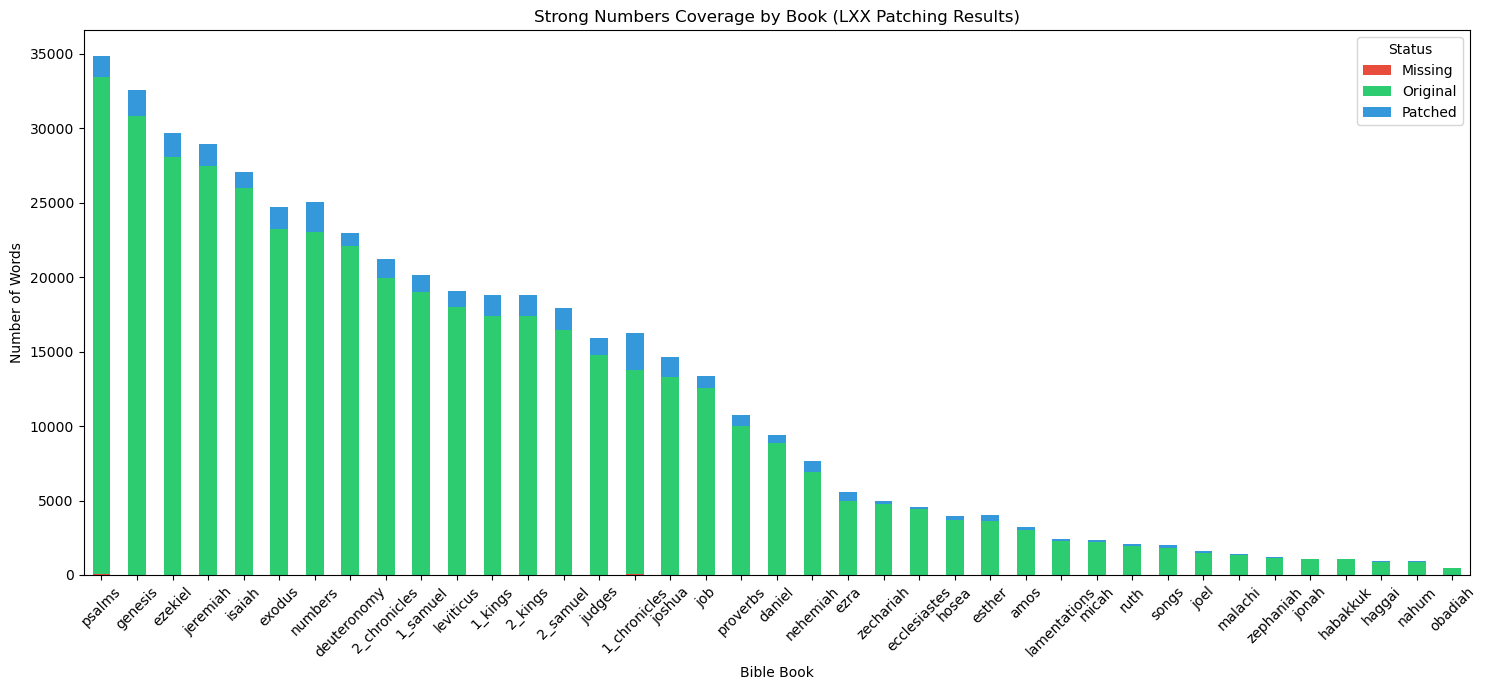

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sagatavojam datus vizualizācijai
# Pieņemam, ka 'is_patched' ir True tiem, ko nupat aizpildīji,
# un 'strong_num' ir NaN tiem, kas joprojām ir tukši.

def plot_strongs_coverage(df):
    # Izveidojam statusa kolonnu
    df['status'] = 'Missing'
    df.loc[df['strong_num'].notna(), 'status'] = 'Original'
    df.loc[df.get('is_patched', False) == True, 'status'] = 'Patched'

    # Sagrupējam datus
    coverage = df.groupby(['book', 'status']).size().unstack(fill_value=0)
    
    # Sakārtojam grāmatas (var izmantot savu idxl secību)
    coverage = coverage.sort_values(by='Original', ascending=False)

    # Zīmējam histogrammu (Stacked Bar Chart)
    coverage.plot(kind='bar', stacked=True, figsize=(15, 7), 
                  color={'Original': '#2ecc71', 'Patched': '#3498db', 'Missing': '#e74c3c'})
    
    plt.title('Strong Numbers Coverage by Book (LXX Patching Results)')
    plt.xlabel('Bible Book')
    plt.ylabel('Number of Words')
    plt.legend(title='Status')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Izsauc funkciju
plot_strongs_coverage(strongs_df)

In [68]:
missing_counts = None
def analyze_missing_words(df, top_n=20):
    # Atlasām vārdus, kuriem joprojām nav Strong numura
    missing = df[df['strong_num'].isna() | (df['strong_num'] == "")]
    
    # Saskaitām biežumu pēc "form" (notīrītas no akcentiem)
    missing_counts = missing['form'].apply(strip_accents).value_counts()
    
    print(f"\n--- Top {top_n} vārdi bez Strong numuriem ---")
    print(missing_counts.head(top_n))
    return missing_counts.head(top_n)

# Izsauc analīzi
top_missing = analyze_missing_words(strongs_df)


--- Top 20 vārdi bez Strong numuriem ---
form
γεδσων      12
γαι          8
αωδ          5
ιεθ          5
αδα          4
αιν          4
δαν          4
αια          3
ωση          3
βωκαι        3
ωσα          3
οζα          3
ιρ           3
παραθεμα     2
σορ          2
μυς          2
σαβαχα       2
ηρα          2
αλα          2
ι            2
Name: count, dtype: int64


In [73]:
pd.set_option('display.max_rows', 290)
print(voids_df[['book', 'chapter', 'verse', 'form']])

                book  chapter  verse          form
2245         genesis        4     19           Αδα
2253         genesis        4     20           Αδα
2301         genesis        4     23           Αδα
5147         genesis       10     12        Νινευη
11803        genesis       22     21            Ωξ
18306        genesis       30     39  ἐγκισσήσωσιν
21960        genesis       35     22        Βαλλας
22466        genesis       36     23           Σωφ
22473        genesis       36     24           Αιε
22508        genesis       36     26         Αμαδα
22733        genesis       36     42        Θαιμαν
31718        genesis       49     17           Δαν
52187         exodus       32     10       ἐκτρίψω
55365         exodus       38      4      παράθεμα
55889         exodus       38     31      παράθεμα
78172        numbers        3     17        Γεδσων
78251        numbers        3     23        Γεδσων
78274        numbers        3     25        Γεδσων
79426        numbers        4  

In [74]:
strongs_df[:2]

,verse,word,form,strong_num,strong_en_title,book,chapter,is_patched,status
0,1,0,ἐν,1722,Prep,genesis,1,NaN,Original
1,1,1,ἀρχῇ,746,N-DSF,genesis,1,NaN,Original


In [87]:
# Definējam kolonnas, kuras vēlamies saglabāt (izlaižot is_patched un status)
save_columns = ["form",	"strong_num",	"strong_en_title",	"book",	"chapter", "verse",	"word", "is_patched"]

strongs_df.to_csv(
    "greek-enh-lxx-apo-OT-blb.csv",
    columns=[col for col in save_columns if col in strongs_df.columns], # Drošībai pārbaudām vai eksistē
    index=False,
    encoding='utf-8',
    quoting=1,  # csv.QUOTE_ALL - ieliek visas vērtības pēdiņās
    escapechar='\\'
)

In [79]:
invalid_values = ["-1", "", "na"]

filtered_df = strongs_df[
    (~strongs_df['strong_num'].isin(invalid_values)) & 
    (strongs_df['strong_num'].notna()) & 
    (strongs_df['strong_num'].str.contains('|', regex=False))
]

In [80]:
len(filtered_df)

3092

In [82]:
ffiltered_df = filtered_df[
(filtered_df['strong_num'].str.split('|').str.len() == 2)
]

In [83]:
len(ffiltered_df)

3078

In [84]:
fffiltered_df = filtered_df[
(filtered_df['strong_num'].str.split('|').str.len() != 2)
]

In [85]:
len(fffiltered_df)+len(ffiltered_df)

3092

In [86]:
fffiltered_df

,verse,word,form,strong_num,strong_en_title,book,chapter,is_patched,status
9972,29,4,ἐκτρῖψαι,1625.3|3588|2316,V-AAN-..,genesis,19,True,Patched
11066,20,16,τοξότης,1510.7.3|3588|2316,N-NSM,genesis,21,True,Patched
54597,30,7,ἀνακέκληκεν,342.1|3588|2316,V-RAI-3S,exodus,35,True,Patched
54603,30,13,Βεσελεηλ,342.1|3588|2316,N-ASM,exodus,35,True,Patched
155430,19,20,Νωεμιν,1487|3778|1510.2.3,N-NSF,ruth,1,True,Patched
167196,9,1,παρήγαγεν,1586|3588|2962,V-AAI-3S,1_samuel,16,True,Patched
240599,11,12,διέκοψεν,1249.2|3588|2316,V-AAI-3S,1_chronicles,14,True,Patched
240609,11,22,διακοπὴν,1249.2|3588|2316,N-ASF,1_chronicles,14,True,Patched
240619,11,32,Διακοπὴ,1249.2|3588|2316,N-NSF,1_chronicles,14,True,Patched
253967,23,9,Σαλωμων,1325|3588|2316,N-GSM,2_chronicles,9,True,Patched


In [ ]:
#akchually, no need to resolve, as these indicate sayings most likely that should
#be visible as grouped